In [133]:
print("📦 Installing dependencies for Capstone Project...\n")

%pip install langchain-groq langchain-community langgraph pypdf pandas -q

print("\n" + "="*70)
print("✅ All dependencies installed successfully!")
print("="*70)
print("\nInstalled packages:")
print("  • langchain-groq")
print("  • langchain-community")
print("  • langgraph")
print("  • pypdf")
print("  • pandas")
print("\n✨ Ready to use capstone.ipynb!")

📦 Installing dependencies for Capstone Project...


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

✅ All dependencies installed successfully!

Installed packages:
  • langchain-groq
  • langchain-community
  • langgraph
  • pypdf
  • pandas

✨ Ready to use capstone.ipynb!


# Install Dependencies for Capstone Project

This cell installs all required packages for the Cease & Desist Document Processing System.

In [134]:
# Standard library imports
import os
import json
import sqlite3
from datetime import datetime
from pathlib import Path
from typing import TypedDict, Optional, Dict, Any
import pandas as pd
from pprint import pprint

# LangChain imports
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.tools import tool

# LangGraph imports
from langgraph.graph import StateGraph, END
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Handle different SqliteSaver import paths for compatibility
try:
    from langgraph.checkpoint.sqlite import SqliteSaver
except ImportError:
    try:
        from langgraph.checkpoint import SqliteSaver
    except ImportError:
        print("⚠️  SqliteSaver import failed - will define as None")
        SqliteSaver = None

# Initialize paths
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data" / "pdfs"
DB_PATH = "cease_desist.db"
ARCHIVE_PATH = "irrelevant_docs.txt"
AUDIT_LOG_PATH = "audit_log.json"

print("✅ All required libraries imported successfully!")
print("\n📁 Project paths initialized:")
print(f"   DATA_DIR: {DATA_DIR}")
print(f"   DB_PATH: {DB_PATH}")
print(f"   ARCHIVE_PATH: {ARCHIVE_PATH}")
print(f"   AUDIT_LOG_PATH: {AUDIT_LOG_PATH}")
print(f"\n✨ SqliteSaver: {'Available' if SqliteSaver else 'Not available in this version'}")

⚠️  SqliteSaver import failed - will define as None
✅ All required libraries imported successfully!

📁 Project paths initialized:
   DATA_DIR: data/pdfs
   DB_PATH: cease_desist.db
   ARCHIVE_PATH: irrelevant_docs.txt
   AUDIT_LOG_PATH: audit_log.json

✨ SqliteSaver: Not available in this version


Load all PDFS from data\pdfs directory

In [135]:
# Create data directory if it doesn't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Load all PDFs from DATA_DIR
def load_pdfs_from_storage() -> Dict[str, str]:
    """Load all PDF files from DATA_DIR and extract text content."""
    pdf_documents = {}
    
    # Check if DATA_DIR exists
    if not DATA_DIR.exists():
        print(f"⚠️  DATA_DIR does not exist: {DATA_DIR}")
        return pdf_documents
    
    # Find all PDF files in DATA_DIR
    pdf_files = list(DATA_DIR.glob("*.pdf"))
    
    if not pdf_files:
        print(f"ℹ️  No PDF files found in: {DATA_DIR}")
        return pdf_documents
    
    print(f"📄 Loading {len(pdf_files)} PDF(s) from DATA_DIR\n")
    print(f"   Path: {DATA_DIR.absolute()}\n")
    
    for pdf_path in pdf_files:
        try:
            loader = PyPDFLoader(str(pdf_path))
            pages = loader.load()
            # Combine all pages into single document
            content = "\n".join([page.page_content for page in pages])
            pdf_documents[pdf_path.name] = content
            print(f"✅ Loaded: {pdf_path.name} ({len(pages)} pages, {len(content)} chars)")
        except Exception as e:
            print(f"❌ Error loading {pdf_path.name}: {str(e)}")
    
    return pdf_documents

# Load PDFs from storage
pdf_storage = load_pdfs_from_storage()
print(f"\n✨ PDF Storage Summary:")
print(f"   Total documents: {len(pdf_storage)}")
if pdf_storage:
    total_chars = sum(len(content) for content in pdf_storage.values())
    print(f"   Total characters: {total_chars:,}")

📄 Loading 29 PDF(s) from DATA_DIR

   Path: /Users/vaishnavi/Downloads/UpdatedTraining-main/day5/capstone-project/data/pdfs

✅ Loaded: LOA3.pdf (1 pages, 1701 chars)
✅ Loaded: LOA2.pdf (1 pages, 1695 chars)
✅ Loaded: LoA1.pdf (1 pages, 1680 chars)
✅ Loaded: 10_breach_of_contract_nda.pdf (2 pages, 3875 chars)
✅ Loaded: LOA5.pdf (1 pages, 1702 chars)
✅ Loaded: LOA4.pdf (1 pages, 1832 chars)
✅ Loaded: LOA6.pdf (1 pages, 3015 chars)
✅ Loaded: LOA7.pdf (2 pages, 7006 chars)
✅ Loaded: 03_trade_secret_misappropriation.pdf (2 pages, 3527 chars)
✅ Loaded: notice_1.pdf (1 pages, 0 chars)
✅ Loaded: bw_doc_1.pdf (1 pages, 0 chars)
✅ Loaded: 07_software_license_violation.pdf (2 pages, 3496 chars)
✅ Loaded: notice_2.pdf (1 pages, 0 chars)
✅ Loaded: bw_doc_3.pdf (1 pages, 0 chars)
✅ Loaded: bw_doc_2.pdf (1 pages, 0 chars)
✅ Loaded: notice_3.pdf (1 pages, 0 chars)
✅ Loaded: 06_harassment_workplace.pdf (2 pages, 3328 chars)
✅ Loaded: notice_4.pdf (1 pages, 0 chars)
✅ Loaded: bw_doc_5.pdf (1 pages, 0 ch

## Section 2: Define State and Initialize LLM

In [136]:
# Define the state structure for document processing workflow
class DocumentProcessingState(TypedDict):
    """State for the cease & desist document processing graph."""
    document_name: str
    document_content: str
    is_cease_desist: bool
    analysis_result: Dict[str, Any]
    messages: list[BaseMessage]
    error: Optional[str]



# Initialize the LLM
llm = ChatGroq(model="llama-3.1-8b-instant",
                temperature=0)


print("✅ State structure defined")
print("✅ LLM initialized successfully")
print(f"   Model: llama-3.1-8b-instant")
print(f"   Purpose: Analyze cease & desist documents")

✅ State structure defined
✅ LLM initialized successfully
   Model: llama-3.1-8b-instant
   Purpose: Analyze cease & desist documents


In [137]:
# Verify GROQ API key is loaded from .env
import os

# Check if GROQ_API_KEY is set
if os.getenv("GROQ_API_KEY"):
    print("✅ GROQ_API_KEY loaded from .env file")
    print(f"   Key length: {len(os.getenv('GROQ_API_KEY'))} characters")
else:
    print("❌ GROQ_API_KEY not found in environment!")
    print("   Please verify your .env file contains: GROQ_API_KEY=your_key_here")

# Verify LLM connection works
print("\n🔄 Testing LLM connection...")
try:
    test_response = llm.invoke("test")
    print("✅ LLM connection verified successfully!")
except Exception as e:
    print(f"❌ LLM connection failed: {str(e)}")

✅ GROQ_API_KEY loaded from .env file
   Key length: 56 characters

🔄 Testing LLM connection...
✅ LLM connection verified successfully!


In [138]:
# Define analysis prompt
analysis_prompt = ChatPromptTemplate.from_template("""
Analyze the following document and determine if it's a Cease & Desist letter.
Provide structured analysis including:
- is_cease_desist: boolean
- document_type: string
- key_claims: list of strings
- entities_involved: list of strings
- severity: string (low/medium/high)

Document:
{content}

Provide response as JSON.
""")

# Create analysis tool
@tool
def analyze_document(content: str) -> Dict[str, Any]:
    """Analyze a document to determine if it's a cease & desist letter."""
    parser = JsonOutputParser(pydantic_object=dict)
    chain = analysis_prompt | llm | parser
    return chain.invoke({"content": content})

## Section 3: Enhanced Classification & Processing System
Three-category classification with database storage, archiving, and HITL

In [139]:
def get_active_document_name(state: Dict[str, Any]) -> str:
    """Return the PDF filename if available, otherwise document_name."""
    return state.get("pdf_filename") or state.get("document_name") or "Unknown PDF"


# Update DocumentProcessingState with new fields
class DocumentProcessingState(TypedDict):
    """Enhanced state for 3-category classification workflow."""
    document_name: str
    document_content: str
    classification: str  # "Cease", "Uncertain", or "Irrelevant"
    classification_reason: str
    analysis_result: Dict[str, Any]
    messages: list[BaseMessage]
    error: Optional[str]
    timestamp: str
    human_review_required: bool
    human_feedback: Optional[str]

# Update LLM with enhanced prompt for 3-category classification
enhanced_analysis_prompt = ChatPromptTemplate.from_template("""
Analyze the following document and classify it into ONE of three categories:

1. "Cease" - Valid Cease & Desist or similar legal request to stop communication
2. "Uncertain" - Might be a cease request but unclear or requires human judgment
3. "Irrelevant" - Not a cease & desist or legal communication

Provide structured analysis as JSON with:
- classification: "Cease", "Uncertain", or "Irrelevant"
- classification_reason: Brief explanation
- document_type: What kind of document (if identifiable)
- key_claims: List of main points (if relevant)
- entities_involved: Organizations/people mentioned
- severity: "high", "medium", "low" (for Cease documents)
- confidence_score: 0-1 confidence in classification

Document:
{content}

Respond ONLY with valid JSON.
""")

# Create enhanced analysis tool
@tool
def classify_document_enhanced(content: str) -> Dict[str, Any]:
    """Classify document into Cease/Uncertain/Irrelevant with detailed analysis."""
    parser = JsonOutputParser(pydantic_object=dict)
    chain = enhanced_analysis_prompt | llm | parser
    return chain.invoke({"content": content})

print("✅ Enhanced classification prompt and tool created!")
print("   Categories: Cease | Uncertain | Irrelevant")

✅ Enhanced classification prompt and tool created!
   Categories: Cease | Uncertain | Irrelevant


In [140]:
# Database agent for storing Cease & Desist requests
class DatabaseAgent:
    """Handle storing cease & desist documents in database."""
    
    def __init__(self, db_path: str):
        self.db_path = db_path
        self.init_database()
    
    def init_database(self):
        """Initialize database schema."""
        try:
            conn = sqlite3.connect(self.db_path)
            cursor = conn.cursor()
            
            # Create cease_requests table
            cursor.execute("""
                CREATE TABLE IF NOT EXISTS cease_requests (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    date_received TEXT NOT NULL,
                    document_name TEXT NOT NULL,
                    document_type TEXT,
                    key_claims TEXT,
                    entities_involved TEXT,
                    severity TEXT,
                    confidence_score REAL,
                    analysis_result TEXT,
                    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
                )
            """)
            
            conn.commit()
            conn.close()
            print(f"✅ Database initialized: {self.db_path}")
        except Exception as e:
            print(f"❌ Database error: {str(e)}")
    
    def store_cease_request(self, state: DocumentProcessingState) -> bool:
        """Store a cease & desist request in the database."""
        try:
            conn = sqlite3.connect(self.db_path)
            cursor = conn.cursor()
            
            analysis = state.get("analysis_result", {})
            # Prefer explicit PDF filename field, otherwise fallback to document_name
            document_name = state.get("pdf_filename") or state.get("document_name") or "Unknown PDF"
            cursor.execute("""
                INSERT INTO cease_requests 
                (date_received, document_name, document_type, key_claims, 
                 entities_involved, severity, confidence_score, analysis_result)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """, (
                state.get("timestamp"),
                document_name,
                analysis.get("document_type", "Unknown"),
                json.dumps(analysis.get("key_claims", [])),
                json.dumps(analysis.get("entities_involved", [])),
                analysis.get("severity", "medium"),
                analysis.get("confidence_score", 0),
                json.dumps(analysis)
            ))
            
            conn.commit()
            conn.close()
            print(f"✅ Stored: {document_name} in database")
            return True
        except Exception as e:
            print(f"❌ Error storing document: {str(e)}")
            return False

# Create database agent
db_agent = DatabaseAgent(DB_PATH)
print("✅ Database agent initialized!")

✅ Database initialized: cease_desist.db
✅ Database agent initialized!


In [141]:
# Archiving agent for irrelevant documents
class ArchivingAgent:
    """Handle archiving irrelevant documents."""
    
    def __init__(self, archive_path: str):
        self.archive_path = archive_path
    
    def archive_document(self, state: DocumentProcessingState) -> bool:
        """Archive an irrelevant document."""
        try:
            archive_name = state.get("pdf_filename") or state.get("document_name")
            with open(self.archive_path, "a") as f:
                f.write(f"{state['timestamp']} | {archive_name}\n")
            print(f"✅ Archived: {archive_name}")
            return True
        except Exception as e:
            print(f"❌ Archive error: {str(e)}")
            return False

# Audit logger for compliance tracking
class AuditLogger:
    """Log all classification decisions and actions."""
    
    def __init__(self, audit_path: str):
        self.audit_path = audit_path
        self.logs = []
    
    def log_classification(self, state: DocumentProcessingState):
        """Log a classification decision."""
        # Use PDF filename explicitly when available
        log_entry = {
            "timestamp": state.get("timestamp"),
            "document_name": state.get("pdf_filename") or state.get("document_name"),
            "classification": state.get("classification"),
            "classification_reason": state.get("classification_reason"),
            "confidence": state.get("analysis_result", {}).get("confidence_score", 0),
            "requires_human_review": state.get("human_review_required", False)
        }
        self.logs.append(log_entry)
        
        # Write to audit file
        try:
            with open(self.audit_path, "a") as f:
                f.write(json.dumps(log_entry) + "\n")
        except Exception as e:
            print(f"⚠️  Audit log write error: {str(e)}")
    
    def print_summary(self):
        """Print audit summary."""
        cease_count = sum(1 for log in self.logs if log["classification"] == "Cease")
        uncertain_count = sum(1 for log in self.logs if log["classification"] == "Uncertain")
        irrelevant_count = sum(1 for log in self.logs if log["classification"] == "Irrelevant")
        
        print("\n📊 Audit Summary:")
        print(f"   Cease Requests: {cease_count}")
        print(f"   Uncertain Cases: {uncertain_count}")
        print(f"   Irrelevant Documents: {irrelevant_count}")
        print(f"   Total Processed: {len(self.logs)}")

# Initialize agents
archive_agent = ArchivingAgent(ARCHIVE_PATH)
audit_logger = AuditLogger(AUDIT_LOG_PATH)

print("✅ Archiving agent initialized!")
print("✅ Audit logger initialized!")

✅ Archiving agent initialized!
✅ Audit logger initialized!


In [142]:
# Enhanced workflow nodes with three classification paths

def classify_document_node(state: DocumentProcessingState) -> DocumentProcessingState:
    """Classify document into Cease/Uncertain/Irrelevant."""
    # Normalize state so PDF filename is always used when present
    state["pdf_filename"] = state.get("pdf_filename") or state.get("document_name")
    active_name = get_active_document_name(state)
    print(f"\n🔍 Classifying: {active_name}")
    
    try:
        analysis = classify_document_enhanced.invoke({"content": state["document_content"]})
        state["analysis_result"] = analysis
        state["classification"] = analysis.get("classification", "Uncertain")
        state["classification_reason"] = analysis.get("classification_reason", "")
        print(f"   ➜ Classification: {state['classification']}")
    except Exception as e:
        state["classification"] = "Uncertain"
        state["classification_reason"] = f"Analysis error: {str(e)}"
        state["error"] = str(e)
        print(f"   ➜ Error - Marked as Uncertain")
    
    audit_logger.log_classification(state)
    return state

def process_cease_request(state: DocumentProcessingState) -> DocumentProcessingState:
    """Process and store a valid cease & desist request."""
    active_name = get_active_document_name(state)
    print(f"\n💾 Processing CEASE request: {active_name}")
    
    state["messages"].append(HumanMessage(
        content=f"Cease & Desist stored: {active_name}"
    ))
    
    success = db_agent.store_cease_request(state)
    if not success:
        state["error"] = "Failed to store in database"
    
    return state

def archive_irrelevant_document(state: DocumentProcessingState) -> DocumentProcessingState:
    """Archive irrelevant documents."""
    active_name = get_active_document_name(state)
    print(f"\n📦 Archiving IRRELEVANT document: {active_name}")
    
    state["messages"].append(HumanMessage(
        content=f"Archived: {active_name}"
    ))
    
    archive_agent.archive_document(state)
    return state

def human_review_node(state: DocumentProcessingState) -> DocumentProcessingState:
    """Human review node - HITL decision before routing to process or archive."""
    print(f"\n👤 HUMAN REVIEW: {state['document_name']}")
    print(f"   Original Classification: {state.get('classification')}")
    
    # In real scenario, human would provide feedback via UI
    # For now, simulate human decision based on confidence
    confidence = state.get("analysis_result", {}).get("confidence_score", 0)
    
    if confidence > 0.6:
        # High confidence - treat as Cease
        state["classification"] = "Cease"
        state["human_feedback"] = "Human approved as Cease & Desist"
        print(f"   👤 Human Decision: CEASE")
    else:
        # Low confidence - archive as irrelevant
        state["classification"] = "Irrelevant"
        state["human_feedback"] = "Human classified as Irrelevant"
        print(f"   👤 Human Decision: IRRELEVANT")
    
    state["messages"].append(HumanMessage(
        content=f"Human Review Complete - {state['human_feedback']}"
    ))
    
    return state

def audit_node(state: DocumentProcessingState) -> DocumentProcessingState:
    """Final audit node - logs all actions and prepares for completion."""
    active_name = get_active_document_name(state)
    print(f"\n📋 AUDIT: {active_name}")
    print(f"   Final Classification: {state.get('classification')}")
    print(f"   Status: Recorded and audited")
    
    # Audit is already logged during classification, this confirms completion
    state["messages"].append(HumanMessage(
        content=f"✅ Audit complete: {state['document_name']}"
    ))
    
    return state

# Build enhanced workflow graph
def create_enhanced_workflow():
    """Create 3-category classification workflow - human review routes to process/archive."""
    workflow = StateGraph(DocumentProcessingState)
    
    # Add nodes
    workflow.add_node("classify", classify_document_node)
    workflow.add_node("process_cease", process_cease_request)
    workflow.add_node("archive_irrelevant", archive_irrelevant_document)
    workflow.add_node("human_review", human_review_node)
    workflow.add_node("audit", audit_node)
    
    # Set entry point
    workflow.set_entry_point("classify")
    
    # Add conditional edges based on initial classification
    def route_after_classification(state):
        classification = state.get("classification", "Uncertain")
        if classification == "Cease":
            return "process_cease"
        elif classification == "Irrelevant":
            return "archive_irrelevant"
        else:  # Uncertain
            return "human_review"
    
    workflow.add_conditional_edges(
        "classify",
        route_after_classification,
        {
            "process_cease": "process_cease",
            "archive_irrelevant": "archive_irrelevant",
            "human_review": "human_review"
        }
    )
    
    # After human review, route based on human decision
    def route_after_human_review(state):
        classification = state.get("classification", "Irrelevant")
        if classification == "Cease":
            return "process_cease"
        else:  # Irrelevant
            return "archive_irrelevant"
    
    workflow.add_conditional_edges(
        "human_review",
        route_after_human_review,
        {
            "process_cease": "process_cease",
            "archive_irrelevant": "archive_irrelevant"
        }
    )
    
    # All paths converge to audit node
    workflow.add_edge("process_cease", "audit")
    workflow.add_edge("archive_irrelevant", "audit")
    
    # Audit node leads to END
    workflow.add_edge("audit", END)
    
    return workflow.compile()

# Create the enhanced graph
enhanced_graph = create_enhanced_workflow()
print("✅ Enhanced 3-category workflow created successfully!")
print("   Routes: Cease → Database | Irrelevant → Archive | Uncertain → Human Review")

✅ Enhanced 3-category workflow created successfully!
   Routes: Cease → Database | Irrelevant → Archive | Uncertain → Human Review


🎨 Rendering Enhanced Graph Visualization



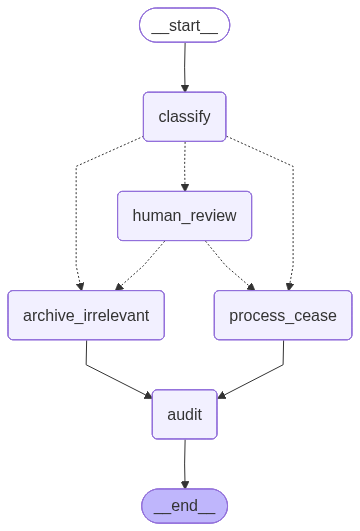

✅ Graph displayed successfully!



In [143]:
# Display the Enhanced Graph Visualization
from IPython.display import Image, display

print("🎨 Rendering Enhanced Graph Visualization\n")
print("=" * 80)

try:
    # Display the graph as PNG
    display(Image(enhanced_graph.get_graph().draw_mermaid_png()))
    print("✅ Graph displayed successfully!")
    
except Exception as e:
    print(f"⚠️  PNG rendering unavailable: {str(e)}")
    print("\nFallback: Displaying Mermaid diagram code...\n")
    
    try:
        mermaid_diagram = enhanced_graph.get_graph().draw_mermaid()
        print(mermaid_diagram)
    except Exception as e2:
        print(f"Error: {str(e2)}")

print("\n" + "=" * 80)

In [144]:
# CLEANUP: Clear old test data before processing actual PDFs
import os

print("=" * 80)
print("🧹 CLEANUP: Clearing Previous Test Data")
print("=" * 80)

# 1. Delete and recreate database
try:
    if os.path.exists(DB_PATH):
        os.remove(DB_PATH)
        print(f"✓ Deleted old database: {DB_PATH}")
    
    # Reinitialize database
    db_agent_new = DatabaseAgent(DB_PATH)
    print(f"✓ Created fresh database: {DB_PATH}")
except Exception as e:
    print(f"❌ Error clearing database: {str(e)}")

# 2. Delete archive file
try:
    if os.path.exists(ARCHIVE_PATH):
        os.remove(ARCHIVE_PATH)
        print(f"✓ Deleted old archive: {ARCHIVE_PATH}")
except Exception as e:
    print(f"❌ Error clearing archive: {str(e)}")

# 3. Delete audit log
try:
    if os.path.exists(AUDIT_LOG_PATH):
        os.remove(AUDIT_LOG_PATH)
        print(f"✓ Deleted old audit log: {AUDIT_LOG_PATH}")
    
    # Reinitialize audit logger
    audit_logger_new = AuditLogger(AUDIT_LOG_PATH)
    print(f"✓ Created fresh audit logger: {AUDIT_LOG_PATH}")
except Exception as e:
    print(f"❌ Error clearing audit log: {str(e)}")

print("\n✅ Cleanup complete - Ready to process actual PDFs with clean storage")
print("=" * 80)

# Update global agents to use fresh instances
db_agent = db_agent_new
audit_logger = audit_logger_new
archive_agent = ArchivingAgent(ARCHIVE_PATH)

print("✅ Global agents updated with fresh instances")

🧹 CLEANUP: Clearing Previous Test Data
✓ Deleted old database: cease_desist.db
✅ Database initialized: cease_desist.db
✓ Created fresh database: cease_desist.db
✓ Deleted old archive: irrelevant_docs.txt
✓ Deleted old audit log: audit_log.json
✓ Created fresh audit logger: audit_log.json

✅ Cleanup complete - Ready to process actual PDFs with clean storage
✅ Global agents updated with fresh instances


In [145]:
# Process actual PDFs from storage through the workflow
print("=" * 80)
print("🔄 PROCESSING ACTUAL PDF FILES FROM STORAGE")
print("=" * 80)

if pdf_storage:
    for pdf_filename, content in pdf_storage.items():
        print(f"\n{'─' * 80}")
        print(f"Processing: {pdf_filename}")
        print(f"{'─' * 80}")
        
        # Initialize state with actual PDF filename
        state = {
            "document_name": pdf_filename,  # Use actual PDF filename
            "pdf_filename": pdf_filename,   # Explicitly set for consistency
            "document_content": content,
            "classification": "Uncertain",
            "classification_reason": "",
            "analysis_result": {},
            "messages": [],
            "error": None,
            "timestamp": datetime.now().isoformat(),
            "human_review_required": False,
            "human_feedback": None
        }
        
        # Run through workflow
        result = enhanced_graph.invoke(state)
        
        # Print result
        print(f"\n✓ Final Classification: {result['classification']}")
        print(f"  Confidence Score: {result.get('analysis_result', {}).get('confidence_score', 'N/A')}")
        if result.get('human_feedback'):
            print(f"  Human Review: {result['human_feedback']}")
else:
    print("ℹ️  No PDF files found in storage to process.")

print(f"\n{'=' * 80}")
print("✅ ACTUAL PDF PROCESSING COMPLETE")
print("=" * 80)

🔄 PROCESSING ACTUAL PDF FILES FROM STORAGE

────────────────────────────────────────────────────────────────────────────────
Processing: LOA3.pdf
────────────────────────────────────────────────────────────────────────────────

🔍 Classifying: LOA3.pdf
   ➜ Classification: Cease

💾 Processing CEASE request: LOA3.pdf
✅ Stored: LOA3.pdf in database

📋 AUDIT: LOA3.pdf
   Final Classification: Cease
   Status: Recorded and audited

✓ Final Classification: Cease
  Confidence Score: 0.9

────────────────────────────────────────────────────────────────────────────────
Processing: LOA2.pdf
────────────────────────────────────────────────────────────────────────────────

🔍 Classifying: LOA2.pdf
   ➜ Classification: Cease

💾 Processing CEASE request: LOA2.pdf
✅ Stored: LOA2.pdf in database

📋 AUDIT: LOA2.pdf
   Final Classification: Cease
   Status: Recorded and audited

✓ Final Classification: Cease
  Confidence Score: 1.0

────────────────────────────────────────────────────────────────────────

In [146]:
# Verify processing outputs across all three storage systems
import os

print("=" * 80)
print("✅ VERIFICATION: Check Database, Archive, and Audit Outputs")
print("=" * 80)

# 1. DATABASE VERIFICATION
print("\n📊 1. DATABASE STORAGE (Cease Requests)")
print("-" * 80)
try:
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute('SELECT COUNT(*) FROM cease_requests')
    count = cursor.fetchone()[0]
    print(f"   Records stored in cease_requests: {count}")
    
    if count > 0:
        cursor.execute('SELECT id, document_name, severity, confidence_score FROM cease_requests')
        rows = cursor.fetchall()
        for row in rows:
            print(f"   ✓ ID {row[0]}: {row[1]} (Severity: {row[2]}, Confidence: {row[3]})")
    
    conn.close()
except Exception as e:
    print(f"   ❌ Error querying database: {str(e)}")

# 2. ARCHIVE VERIFICATION
print("\n📦 2. ARCHIVE STORAGE (Irrelevant Documents)")
print("-" * 80)
if os.path.exists(ARCHIVE_PATH):
    try:
        with open(ARCHIVE_PATH, 'r') as f:
            archive_lines = f.readlines()
        print(f"   Records in archive: {len(archive_lines)}")
        for line in archive_lines:
            print(f"   ✓ {line.strip()}")
    except Exception as e:
        print(f"   ❌ Error reading archive: {str(e)}")
else:
    print(f"   ℹ️  Archive file not created yet (will be created when irrelevant docs are archived)")

# 3. AUDIT LOG VERIFICATION
print("\n📋 3. AUDIT LOG (All Classification Decisions)")
print("-" * 80)
if os.path.exists(AUDIT_LOG_PATH):
    try:
        with open(AUDIT_LOG_PATH, 'r') as f:
            audit_lines = f.readlines()
        print(f"   Total audit records: {len(audit_lines)}")
        
        # Parse and categorize
        cease_count = 0
        uncertain_count = 0
        irrelevant_count = 0
        
        for line in audit_lines:
            record = json.loads(line)
            classification = record.get('classification', 'Unknown')
            if classification == 'Cease':
                cease_count += 1
            elif classification == 'Uncertain':
                uncertain_count += 1
            elif classification == 'Irrelevant':
                irrelevant_count += 1
            print(f"   ✓ {record['document_name']}: {classification} (Confidence: {record['confidence']:.2f})")
        
        print(f"\n   Summary:")
        print(f"      Cease Requests: {cease_count}")
        print(f"      Uncertain Cases: {uncertain_count}")
        print(f"      Irrelevant Documents: {irrelevant_count}")
        
    except Exception as e:
        print(f"   ❌ Error reading audit log: {str(e)}")
else:
    print(f"   ℹ️  Audit log not created yet")

print("\n" + "=" * 80)
print("🎯 PROCESSING SUMMARY")
print("=" * 80)
print("""
✅ Cease Requests  → DatabaseAgent.store_cease_request()
   Stores: Document name, date received, extracted details (type, claims, entities, severity)
   
✅ Irrelevant Docs → ArchivingAgent.archive_document()
   Stores: Document name, date received (flat file format)
   
✅ Uncertain Cases → human_review_node() → Re-routes to Cease or Archive
   Then: Stored in appropriate destination (database or archive)
   
✅ All Decisions   → AuditLogger.log_classification()
   Logs: Complete audit trail with timestamp, classification, confidence, human feedback
""")


✅ VERIFICATION: Check Database, Archive, and Audit Outputs

📊 1. DATABASE STORAGE (Cease Requests)
--------------------------------------------------------------------------------
   Records stored in cease_requests: 19
   ✓ ID 1: LOA3.pdf (Severity: high, Confidence: 0.9)
   ✓ ID 2: LOA2.pdf (Severity: high, Confidence: 1.0)
   ✓ ID 3: LoA1.pdf (Severity: high, Confidence: 0.9)
   ✓ ID 4: 10_breach_of_contract_nda.pdf (Severity: high, Confidence: 1.0)
   ✓ ID 5: LOA5.pdf (Severity: high, Confidence: 0.9)
   ✓ ID 6: LOA4.pdf (Severity: high, Confidence: 0.9)
   ✓ ID 7: LOA6.pdf (Severity: high, Confidence: 0.9)
   ✓ ID 8: LOA7.pdf (Severity: high, Confidence: 0.9)
   ✓ ID 9: 03_trade_secret_misappropriation.pdf (Severity: high, Confidence: 1.0)
   ✓ ID 10: 07_software_license_violation.pdf (Severity: high, Confidence: 1.0)
   ✓ ID 11: 06_harassment_workplace.pdf (Severity: high, Confidence: 1.0)
   ✓ ID 12: 05_patent_infringement_medical_device.pdf (Severity: high, Confidence: 1.0)
   

In [147]:
# Retrieve row count from cease_requests table
import sqlite3

print("=" * 80)
print("📊 CEASE REQUESTS TABLE - ROW COUNT")
print("=" * 80)

try:
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    # Get total row count
    cursor.execute('SELECT COUNT(*) FROM cease_requests')
    total_count = cursor.fetchone()[0]
    
    print(f"\n✅ Total rows in cease_requests table: {total_count}")
    
    # Get breakdown by classification (if available)
    print("\n📋 Breakdown by details:")
    cursor.execute('''
        SELECT 
            severity,
            COUNT(*) as count
        FROM cease_requests
        GROUP BY severity
        ORDER BY count DESC
    ''')
    
    severity_breakdown = cursor.fetchall()
    if severity_breakdown:
        for severity, count in severity_breakdown:
            print(f"   • Severity '{severity}': {count} record(s)")
    
    conn.close()
    
    print(f"\n" + "=" * 80)
    
except Exception as e:
    print(f"❌ Error retrieving row count: {str(e)}")


📊 CEASE REQUESTS TABLE - ROW COUNT

✅ Total rows in cease_requests table: 19

📋 Breakdown by details:
   • Severity 'high': 19 record(s)

